<a href="https://colab.research.google.com/github/prameela-rani-patnaik/Student_Performance_Analysis./blob/main/M1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [82]:
!pip install pandas numpy matplotlib scikit-learn joblib


In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [84]:
df=pd.read_csv(r"student_exam_performance_dataset.csv")

In [85]:
df.head()


,student_id,gender,age,parental_education,family_income,internet_access,study_environment,study_hours_per_day,attendance_rate,sleep_hours,...,online_courses_completed,tutoring,math_score,reading_score,writing_score,science_score,final_exam_score,previous_gpa,pass_fail,grade_category
0,S00001,Male,17,High School,Medium,Yes,Quiet,2.98,96.5,6.05,...,1,Yes,42.8,62.4,54.8,51.8,49.1,2.44,Fail,F
1,S00002,Female,18,High School,Low,Yes,Quiet,4.45,95.7,6.96,...,0,Yes,77.9,73.5,64.4,61.6,70.1,2.79,Pass,C
2,S00003,Male,17,High School,Medium,No,Quiet,3.75,76.0,7.02,...,4,Yes,53.5,38.3,36.3,47.1,42.2,1.49,Fail,F
3,S00004,Male,18,Bachelor,Medium,Yes,Quiet,2.03,72.6,6.23,...,4,No,28.3,23.5,32.0,39.0,31.9,1.34,Fail,F
4,S00005,Male,18,Bachelor,Medium,Yes,Quiet,5.14,87.3,8.54,...,0,No,74.7,54.9,73.6,55.5,66.4,2.60,Pass,C


In [86]:
df.shape


(10000, 23)

In [87]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  10000 non-null  object 
 1   gender                      10000 non-null  object 
 2   age                         10000 non-null  int64  
 3   parental_education          10000 non-null  object 
 4   family_income               10000 non-null  object 
 5   internet_access             10000 non-null  object 
 6   study_environment           10000 non-null  object 
 7   study_hours_per_day         10000 non-null  float64
 8   attendance_rate             10000 non-null  float64
 9   sleep_hours                 10000 non-null  float64
 10  social_media_hours          10000 non-null  float64
 11  assignment_completion_rate  10000 non-null  float64
 12  participation_score         10000 non-null  float64
 13  online_courses_completed    1000

In [88]:
df.describe()

,age,study_hours_per_day,attendance_rate,sleep_hours,social_media_hours,assignment_completion_rate,participation_score,online_courses_completed,math_score,reading_score,writing_score,science_score,final_exam_score,previous_gpa
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,16.486900,3.019702,84.703770,7.018894,2.51730,79.491450,69.81681,2.029300,49.503410,49.755600,49.650940,49.759010,49.681910,1.984944
std,1.122744,1.179235,9.509211,0.991714,1.44675,13.763237,14.65927,1.437445,13.879156,13.359603,13.436917,13.825207,12.149823,0.544920
min,15.000000,0.500000,50.800000,4.000000,0.00000,40.000000,20.00000,0.000000,0.000000,0.000000,0.000000,4.800000,4.400000,0.000000
25%,15.000000,2.200000,78.275000,6.337500,1.50000,70.200000,59.80000,1.000000,40.000000,40.800000,40.700000,40.300000,41.600000,1.610000
50%,16.000000,3.010000,85.100000,7.030000,2.50000,80.000000,69.90000,2.000000,49.300000,49.600000,49.600000,49.600000,49.550000,1.990000
75%,17.000000,3.830000,91.900000,7.690000,3.50000,90.000000,80.10000,3.000000,58.600000,58.500000,58.600000,59.000000,57.600000,2.350000
max,18.000000,7.240000,100.000000,10.000000,8.00000,100.000000,100.00000,9.000000,100.000000,100.000000,100.000000,100.000000,97.800000,3.990000


In [89]:
df.isnull()

,student_id,gender,age,parental_education,family_income,internet_access,study_environment,study_hours_per_day,attendance_rate,sleep_hours,...,online_courses_completed,tutoring,math_score,reading_score,writing_score,science_score,final_exam_score,previous_gpa,pass_fail,grade_category
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [90]:
df.isnull().count()

,0
student_id,10000
gender,10000
age,10000
parental_education,10000
family_income,10000
internet_access,10000
study_environment,10000
study_hours_per_day,10000
attendance_rate,10000
sleep_hours,10000


In [91]:
# Create target
df['pass_fail'] = (df['math_score'] >= 40).astype(int)

X = df[['study_hours_per_day', 'math_score']]
y = df['pass_fail']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

model.fit(X_train_scaled, y_train)

LogisticRegression()

In [96]:
X_train

,study_hours_per_day,math_score
9069,3.87,63.0
2603,0.50,32.3
7738,3.26,55.2
1579,4.96,69.8
5058,3.22,60.3
...,...,...
5734,4.40,55.3
5191,2.84,56.8
5390,1.62,27.9
860,0.73,36.7


In [102]:
y_train

,pass_fail
9069,1
2603,0
7738,1
1579,1
5058,1
...,...
5734,1
5191,1
5390,0
860,0


In [97]:
X_test

,study_hours_per_day,math_score
6252,2.65,47.3
4684,2.59,49.4
1731,1.66,35.8
4742,3.44,65.3
4521,3.65,53.7
...,...,...
8014,2.62,45.9
1074,2.53,45.2
3063,2.98,50.1
6487,3.08,44.2


In [100]:
y_test

,pass_fail
6252,1
4684,1
1731,0
4742,1
4521,1
...,...
8014,1
1074,1
3063,1
6487,1


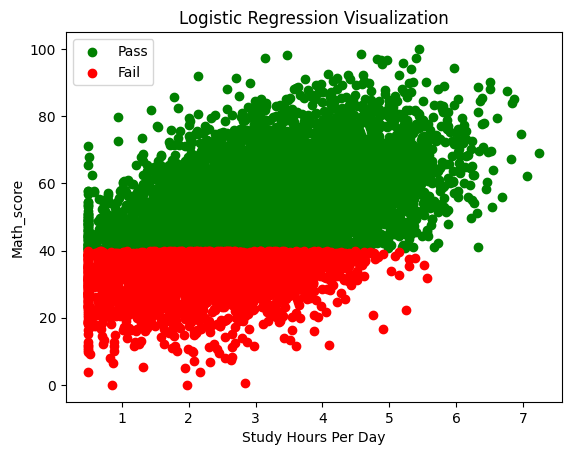

In [92]:
import matplotlib.pyplot as plt

# Separate classes
pass_students = df[df['pass_fail'] == 1]
fail_students = df[df['pass_fail'] == 0]

# Pass points - green
plt.scatter(
    pass_students['study_hours_per_day'],
    pass_students['math_score'],
    color='green',
    label='Pass'
)

# Fail points - red
plt.scatter(
    fail_students['study_hours_per_day'],
    fail_students['math_score'],
    color='red',
    label='Fail'
)

# Labels
plt.xlabel("Study Hours Per Day")
plt.ylabel("Math_score")
plt.title("Logistic Regression Visualization")

plt.legend()

plt.show()

In [93]:
new_data = pd.DataFrame({
    'study_hours_per_day': [6],
    'math_score': [85]
})

new_data_scaled = scaler.transform(new_data)

print(model.predict(new_data_scaled))
print(model.predict_proba(new_data_scaled))

[1]
[[0. 1.]]


In [94]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9993333333333333


In [95]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 768    2]
 [   0 2230]]


In [103]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 1.0
